In [ ]:
# bootstrap: make src/ importable
import sys, os
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), '..', '..')))

# CSIRO Image2Biomass — CHARMS Pipeline with Diagnostics

## What CHARMS actually does

**CHARMS** (Cross-modal Heuristic Auxiliary Representation via Metadata Supervision) addresses a specific problem in precision agriculture: during *training*, you have rich tabular metadata per image (NDVI, canopy height, location, season). At *test/deployment* time, you only have the image.

The solution is a multi-task training regime:

```
  ┌─────────────────────────────────────────────────────────────────┐
  │ TRAINING                                                        │
  │                                                                 │
  │  Image ──► CNN backbone ──► visual features                     │
  │                                   │                             │
  │                    ┌──────────────┤                             │
  │                    │              │                             │
  │             Metadata embed    visual features                   │
  │          (NDVI, ht, state, mo)    │                             │
  │                    │              │                             │
  │                    └──► concat ───┤                             │
  │                                   │                             │
  │                         ┌─────────┴──────────────┐              │
  │                         ▼                         ▼             │
  │                  Biomass heads             Aux heads            │
  │                (5 targets, main)    (NDVI recon, height,        │
  │                                      state, month — forces      │
  │                                      visual features to         │
  │                                      encode physiology)         │
  └─────────────────────────────────────────────────────────────────┘

  ┌─────────────────────────────────────────────────────────────────┐
  │ INFERENCE                                                       │
  │                                                                 │
  │  Image ──► CNN backbone ──► visual features                     │
  │                                   │                             │
  │                        metadata = zeros                         │
  │                                   │                             │
  │                         Biomass head only ──► 5 predictions     │
  │                    (aux heads discarded)                        │
  └─────────────────────────────────────────────────────────────────┘
```

**Why does this help?**  
The auxiliary heads act as a learning signal that forces the CNN to develop feature maps encoding NDVI-relevant (greenness, reflectance), height-relevant (texture density, shadow), and seasonal (colour temperature, dryness) information. Without this pressure, a vanilla CNN might learn shortcuts (e.g., image brightness) that don't generalise.

**Key implementation choices in this pipeline vs. a naive approach:**

| Choice | Naive baseline | This pipeline | Reason |
|---|---|---|---|
| Metadata at train time | Ignored | Fused into regression head | Directly improves training accuracy |
| Loss weighting | Fixed scalars | Learned log-variance (Kendall & Gal) | Adapts to per-target noise |
| Target transform | Raw grams | log1p | Biomass is right-skewed |
| Backbone | ResNet-50 | EfficientNet-V2-S | Better texture features per FLOP |
| Inference | Single pass | 4× TTA (H+V flips) | Top-view images have no canonical orientation |

In [1]:
import os, math, random
import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from sklearn.model_selection import GroupKFold
from sklearn.preprocessing import StandardScaler

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
import torchvision.models as models

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print('DEVICE:', DEVICE)

# Style for all plots
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.grid': True, 'grid.alpha': 0.3,
    'axes.spines.top': False, 'axes.spines.right': False,
    'font.size': 11,
})

DEVICE: cpu


In [2]:
TRAIN_CSV    = '../../../data/tabular/train/train.csv'
TEST_CSV     = '../../../data/tabular/test/test.csv'
IMAGE_FOLDER = '../../../data/image'

SEED        = 42
BATCH_SIZE  = 16
NUM_WORKERS = 0
EPOCHS      = 4
LR          = 2e-4
WEIGHT_DECAY= 1e-4
IMG_SIZE    = 384
N_FOLDS     = 4

TARGETS       = ['Dry_Green_g', 'Dry_Dead_g', 'Dry_Clover_g', 'GDM_g', 'Dry_Total_g']
NUMERIC_ATTRS = ['Pre_GSHH_NDVI', 'Height_Ave_cm']
TARGET_COLORS = ['#2196F3', '#FF9800', '#4CAF50', '#9C27B0', '#F44336']

def seed_everything(seed=42):
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)

seed_everything(SEED)

## 1. Exploratory Data Analysis

Before modelling, we need to understand the data distribution. Key questions:
- Are the targets skewed? (→ log transform decision)
- How correlated are the 5 targets?
- Does NDVI correlate with biomass? (→ validates the CHARMS auxiliary task)
- Is there seasonal variation?

### 📊 What good plots look like:
- **Target histograms**: should show strong right-skew (most samples have low biomass, a few are very high)
- **Correlation heatmap**: Dry_Total_g should correlate strongly with all others. Dry_Clover_g may be weakly correlated with Dry_Dead_g
- **NDVI vs Total**: R² of ~0.4–0.6 is typical — NDVI is a useful but imperfect proxy

In [3]:
def make_wide_train(train_csv):
    df = pd.read_csv(train_csv)
    meta_cols = ['sample_id', 'image_path', 'Sampling_Date', 'State', 'Species',
                 'Pre_GSHH_NDVI', 'Height_Ave_cm']
    meta = df[meta_cols].drop_duplicates('image_path').copy()
    y = (df.pivot_table(index='image_path', columns='target_name',
                        values='target', aggfunc='first').reset_index())
    out = meta.merge(y, on='image_path', how='inner')
    out['Sampling_Date'] = pd.to_datetime(out['Sampling_Date'])
    out['month'] = out['Sampling_Date'].dt.month.astype(int)
    return out

train_df = make_wide_train(TRAIN_CSV)
print(f'Dataset: {len(train_df)} images, {train_df["State"].nunique()} states')
train_df[TARGETS].describe().round(1)

Dataset: 357 images, 4 states


,Dry_Green_g,Dry_Dead_g,Dry_Clover_g,GDM_g,Dry_Total_g
count,357.0,357.0,357.0,357.0,357.0
mean,26.6,12.0,6.6,33.3,45.3
std,25.4,12.4,12.1,24.9,28.0
min,0.0,0.0,0.0,1.0,1.0
25%,8.8,3.2,0.0,16.0,25.3
50%,20.8,8.0,1.4,27.1,40.3
75%,35.1,17.6,7.2,43.7,57.9
max,158.0,83.8,71.8,158.0,185.7


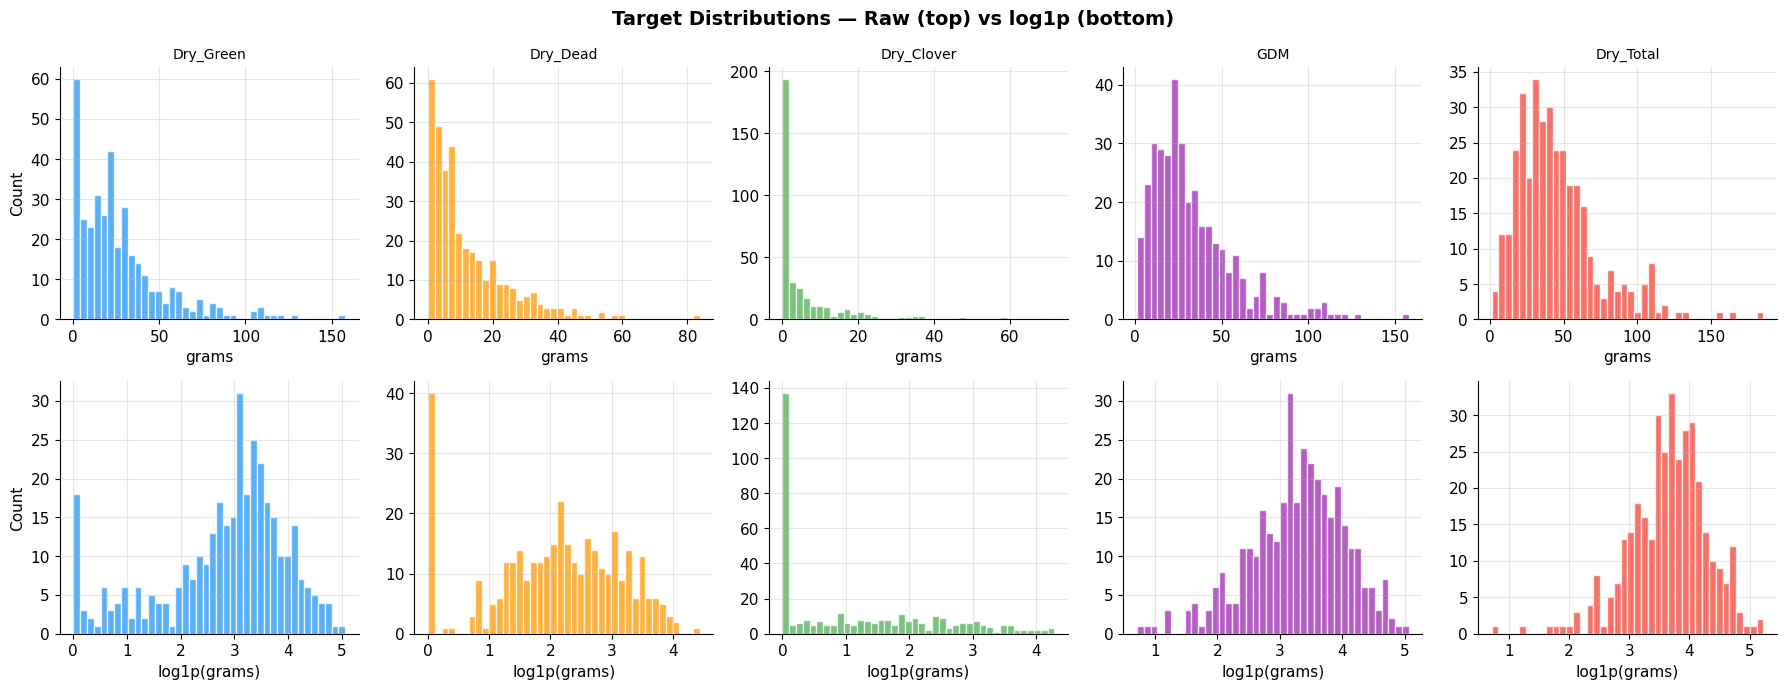


✅ WHAT TO LOOK FOR:
  - TOP ROW: strong right-skew is expected and normal. Most quadrats have 0–100g,
    but a few reach 300–500g. This skew is why we apply log1p.
  - BOTTOM ROW: after log1p the distributions should look roughly bell-shaped.
    If they're still very skewed, consider sqrt or cube-root transform instead.
  - Dry_Clover_g typically has MANY zeros (clover is not always present).
    This is expected.



In [4]:
# ── Plot 1: Target distributions (raw and log-transformed) ──────────────────
fig, axes = plt.subplots(2, 5, figsize=(18, 7))
fig.suptitle('Target Distributions — Raw (top) vs log1p (bottom)', fontsize=14, fontweight='bold')

for i, (col, color) in enumerate(zip(TARGETS, TARGET_COLORS)):
    vals = train_df[col].dropna()
    axes[0, i].hist(vals, bins=40, color=color, alpha=0.75, edgecolor='white')
    axes[0, i].set_title(col.replace('_g', ''), fontsize=10)
    axes[0, i].set_xlabel('grams')

    log_vals = np.log1p(vals.clip(lower=0))
    axes[1, i].hist(log_vals, bins=40, color=color, alpha=0.75, edgecolor='white')
    axes[1, i].set_xlabel('log1p(grams)')

axes[0, 0].set_ylabel('Count')
axes[1, 0].set_ylabel('Count')
plt.tight_layout()
plt.savefig('plot_01_target_distributions.png', dpi=120, bbox_inches='tight')
plt.show()

print("""
✅ WHAT TO LOOK FOR:
  - TOP ROW: strong right-skew is expected and normal. Most quadrats have 0–100g,
    but a few reach 300–500g. This skew is why we apply log1p.
  - BOTTOM ROW: after log1p the distributions should look roughly bell-shaped.
    If they're still very skewed, consider sqrt or cube-root transform instead.
  - Dry_Clover_g typically has MANY zeros (clover is not always present).
    This is expected.
""")

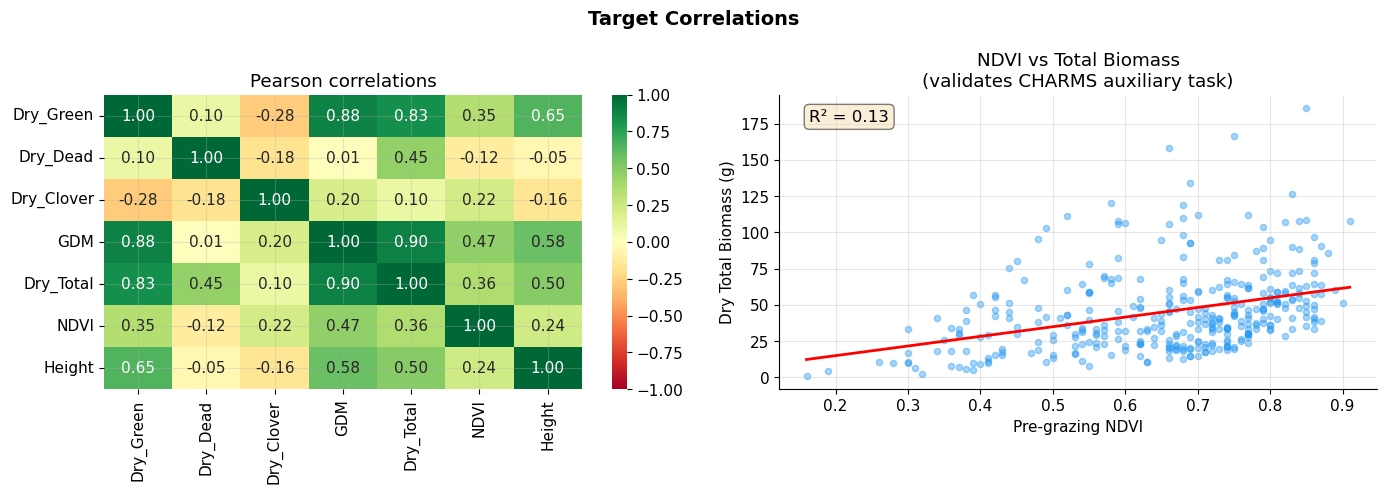


✅ WHAT TO LOOK FOR:
  - HEATMAP: Dry_Total_g should correlate strongly (>0.7) with Dry_Green_g and GDM_g.
    Dry_Clover_g is typically the weakest correlate (sparse presence).
  - NDVI scatter: R² of 0.3–0.6 means NDVI is a useful but incomplete predictor.
    If R² < 0.2, the auxiliary NDVI head may be too easy or too noisy.
    A high R² (>0.7) is suspicious — check for data leakage.
    This moderate correlation is exactly why CHARMS is valuable: the CNN must
    learn to combine NDVI-like features WITH visual texture for best performance.



In [5]:
# ── Plot 2: Correlation matrix ───────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Target Correlations', fontsize=14, fontweight='bold')

corr_cols = TARGETS + ['Pre_GSHH_NDVI', 'Height_Ave_cm']
short = [c.replace('_g','').replace('Pre_GSHH_','').replace('_Ave_cm','') for c in corr_cols]

corr = train_df[corr_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)

sns.heatmap(corr, ax=ax1, annot=True, fmt='.2f', cmap='RdYlGn', center=0,
            xticklabels=short, yticklabels=short, vmin=-1, vmax=1)
ax1.set_title('Pearson correlations')

# Scatter: NDVI vs Total biomass
ax2.scatter(train_df['Pre_GSHH_NDVI'], train_df['Dry_Total_g'],
            alpha=0.4, s=20, color='#2196F3')
ax2.set_xlabel('Pre-grazing NDVI')
ax2.set_ylabel('Dry Total Biomass (g)')
ax2.set_title('NDVI vs Total Biomass\n(validates CHARMS auxiliary task)')

# Add trend line
valid = train_df[['Pre_GSHH_NDVI','Dry_Total_g']].dropna()
z = np.polyfit(valid['Pre_GSHH_NDVI'], valid['Dry_Total_g'], 1)
p = np.poly1d(z)
xr = np.linspace(valid['Pre_GSHH_NDVI'].min(), valid['Pre_GSHH_NDVI'].max(), 100)
ax2.plot(xr, p(xr), 'r-', linewidth=2, label='Linear fit')
r2 = np.corrcoef(valid['Pre_GSHH_NDVI'], valid['Dry_Total_g'])[0,1]**2
ax2.text(0.05, 0.95, f'R² = {r2:.2f}', transform=ax2.transAxes,
         fontsize=12, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.savefig('plot_02_correlations.png', dpi=120, bbox_inches='tight')
plt.show()

print("""
✅ WHAT TO LOOK FOR:
  - HEATMAP: Dry_Total_g should correlate strongly (>0.7) with Dry_Green_g and GDM_g.
    Dry_Clover_g is typically the weakest correlate (sparse presence).
  - NDVI scatter: R² of 0.3–0.6 means NDVI is a useful but incomplete predictor.
    If R² < 0.2, the auxiliary NDVI head may be too easy or too noisy.
    A high R² (>0.7) is suspicious — check for data leakage.
    This moderate correlation is exactly why CHARMS is valuable: the CNN must
    learn to combine NDVI-like features WITH visual texture for best performance.
""")

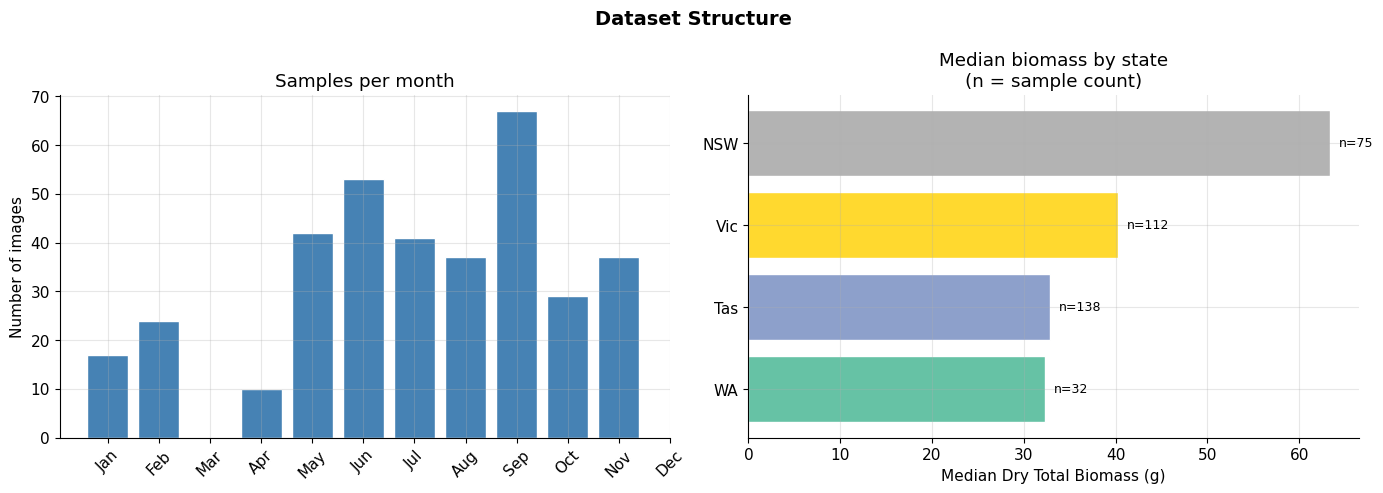


✅ WHAT TO LOOK FOR:
  - MONTHS: expect higher sampling in spring/summer (growing season).
    Imbalance is OK — we don't resample, but it does explain why 'month' 
    is a useful auxiliary signal.
  - STATES: significant differences in median biomass across states are expected
    (different climates). This is why 'State' as an auxiliary classification
    task helps the model — it learns location-specific feature patterns.



In [6]:
# ── Plot 3: Seasonal and geographic breakdown ────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Dataset Structure', fontsize=14, fontweight='bold')

# Samples per month
month_counts = train_df['month'].value_counts().sort_index()
month_names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
ax1.bar(month_counts.index, month_counts.values, color='steelblue', edgecolor='white')
ax1.set_xticks(range(1,13))
ax1.set_xticklabels([month_names[i-1] for i in range(1,13)], rotation=45)
ax1.set_ylabel('Number of images')
ax1.set_title('Samples per month')

# Biomass by state
state_biomass = train_df.groupby('State')['Dry_Total_g'].median().sort_values()
state_counts  = train_df['State'].value_counts()
colors = plt.cm.Set2(np.linspace(0, 1, len(state_biomass)))
bars = ax2.barh(state_biomass.index,
                state_biomass.values,
                color=colors, edgecolor='white')
for bar, state in zip(bars, state_biomass.index):
    ax2.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
             f'n={state_counts[state]}', va='center', fontsize=9)
ax2.set_xlabel('Median Dry Total Biomass (g)')
ax2.set_title('Median biomass by state\n(n = sample count)')

plt.tight_layout()
plt.savefig('plot_03_dataset_structure.png', dpi=120, bbox_inches='tight')
plt.show()

print("""
✅ WHAT TO LOOK FOR:
  - MONTHS: expect higher sampling in spring/summer (growing season).
    Imbalance is OK — we don't resample, but it does explain why 'month' 
    is a useful auxiliary signal.
  - STATES: significant differences in median biomass across states are expected
    (different climates). This is why 'State' as an auxiliary classification
    task helps the model — it learns location-specific feature patterns.
""")

## 2. Data Preparation

In [7]:
# Apply log1p transform
for col in TARGETS:
    train_df[col] = np.log1p(train_df[col].clip(lower=0).astype(np.float32))

# Load test
test_long_df = pd.read_csv(TEST_CSV)
test_df = test_long_df[['sample_id','image_path']].drop_duplicates('image_path').copy()

def fit_metadata_encoders(train_df):
    df = train_df.copy()
    scaler = StandardScaler()
    df[NUMERIC_ATTRS] = scaler.fit_transform(df[NUMERIC_ATTRS].astype(np.float32))
    state_vocab = {k: i for i, k in enumerate(sorted(df['State'].dropna().unique()))}
    df['State_id']  = df['State'].map(state_vocab).astype(int)
    df['month_id']  = (df['month'] - 1).clip(0, 11).astype(int)
    return df, {'scaler': scaler, 'state_vocab': state_vocab,
                'num_states': len(state_vocab), 'num_months': 12}

def apply_metadata_encoders(df, enc):
    df = df.copy()
    if all(c in df.columns for c in NUMERIC_ATTRS):
        df[NUMERIC_ATTRS] = enc['scaler'].transform(df[NUMERIC_ATTRS].astype(np.float32))
    else:
        for c in NUMERIC_ATTRS: df[c] = 0.0
    df['State_id'] = df['State'].map(enc['state_vocab']).fillna(0).astype(int) if 'State' in df.columns else 0
    df['month_id'] = (df['month']-1).clip(0,11).astype(int) if 'month' in df.columns else 0
    return df

train_df, encoders = fit_metadata_encoders(train_df)
test_df = apply_metadata_encoders(test_df, encoders)
print('Encoders:', {k: v for k, v in encoders.items() if k != 'scaler'})

Encoders: {'state_vocab': {'NSW': 0, 'Tas': 1, 'Vic': 2, 'WA': 3}, 'num_states': 4, 'num_months': 12}


## 3. Augmentation & Dataset

In [8]:
train_tfms = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.RandomHorizontalFlip(p=0.5),
    T.RandomVerticalFlip(p=0.5),
    T.RandomRotation(90),
    T.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.15, hue=0.05),
    T.RandomGrayscale(p=0.02),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

valid_tfms = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

class BiomassDataset(Dataset):
    def __init__(self, df, image_root, transforms=None, is_test=False):
        self.df = df.reset_index(drop=True).copy()
        self.image_root = image_root
        self.transforms = transforms
        self.is_test = is_test

    def __len__(self): return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(os.path.join(self.image_root, row['image_path'])).convert('RGB')
        if self.transforms: img = self.transforms(img)
        x_num = torch.tensor([row['Pre_GSHH_NDVI'], row['Height_Ave_cm']], dtype=torch.float32)
        x_cat = torch.tensor([row['State_id'], row['month_id']], dtype=torch.long)
        item = {'image': img, 'image_path': row['image_path'], 'x_num': x_num, 'x_cat': x_cat}
        if not self.is_test:
            item['targets'] = torch.tensor(row[TARGETS].values.astype(np.float32), dtype=torch.float32)
        return item

## 4. Model — CHARMS Architecture

In [9]:
class MetadataEmbedder(nn.Module):
    def __init__(self, num_states, num_months=12, embed_dim=64, out_dim=128):
        super().__init__()
        self.state_emb = nn.Embedding(num_states+1, embed_dim//2, padding_idx=0)
        self.month_emb = nn.Embedding(num_months,   embed_dim//2)
        self.num_fc = nn.Sequential(nn.Linear(2, 64), nn.ReLU())
        self.out_fc = nn.Sequential(nn.Linear(embed_dim+64, out_dim), nn.ReLU())

    def forward(self, x_num, x_cat):
        state_e = self.state_emb(x_cat[:, 0]).squeeze(1)
        month_e = self.month_emb(x_cat[:, 1]).squeeze(1)
        cat_e   = torch.cat([state_e, month_e], dim=1)
        num_e   = self.num_fc(x_num)
        return self.out_fc(torch.cat([cat_e, num_e], dim=1))


class BiomassCharms(nn.Module):
    def __init__(self, num_states, num_months=12, meta_embed_dim=128):
        super().__init__()
        efn = models.efficientnet_v2_s(weights=models.EfficientNet_V2_S_Weights.IMAGENET1K_V1)
        feat_dim = efn.classifier[1].in_features
        efn.classifier = nn.Identity()
        self.backbone = efn
        self.feat_dim = feat_dim
        self.meta_emb = MetadataEmbedder(num_states, num_months, out_dim=meta_embed_dim)
        fused_dim = feat_dim + meta_embed_dim
        self.fusion = nn.Sequential(nn.Linear(fused_dim, 512), nn.ReLU(), nn.Dropout(0.3))
        self.reg_head = nn.Sequential(
            nn.Linear(512, 256), nn.ReLU(), nn.Dropout(0.2), nn.Linear(256, len(TARGETS)))
        self.log_var_head = nn.Linear(512, len(TARGETS))
        self.ndvi_head   = nn.Linear(feat_dim, 1)
        self.height_head = nn.Linear(feat_dim, 1)
        self.state_head  = nn.Linear(feat_dim, num_states)
        self.month_head  = nn.Linear(feat_dim, num_months)

    def forward(self, x, x_num, x_cat):
        visual = self.backbone(x)
        meta   = self.meta_emb(x_num, x_cat)
        fused  = self.fusion(torch.cat([visual, meta], dim=1))
        return {
            'y':       self.reg_head(fused),
            'log_var': self.log_var_head(fused),
            'ndvi':    self.ndvi_head(visual).squeeze(1),
            'height':  self.height_head(visual).squeeze(1),
            'state':   self.state_head(visual),
            'month':   self.month_head(visual),
        }


class CharmsLoss(nn.Module):
    def __init__(self, aux_weight=0.25):
        super().__init__()
        self.aux_weight = aux_weight
        self.mse = nn.MSELoss()
        self.ce  = nn.CrossEntropyLoss()

    def forward(self, out, y, x_num, x_cat):
        log_var   = out['log_var']
        precision = torch.exp(-log_var)
        residual  = F.smooth_l1_loss(out['y'], y, reduction='none')
        loss_main = (precision * residual + log_var).mean()
        loss_aux  = (self.mse(out['ndvi'], x_num[:,0]) + self.mse(out['height'], x_num[:,1])
                     + self.ce(out['state'], x_cat[:,0]) + self.ce(out['month'], x_cat[:,1]))
        loss = loss_main + self.aux_weight * loss_aux
        return loss, {'loss': loss.item(), 'loss_main': loss_main.item(), 'loss_aux': loss_aux.item()}


def r2_per_target(y_true, y_pred):
    ss_res = np.sum((y_true - y_pred)**2, axis=0)
    ss_tot = np.sum((y_true - y_true.mean(axis=0, keepdims=True))**2, axis=0)
    return 1 - ss_res / np.clip(ss_tot, 1e-12, None)

def weighted_global_r2(y_true, y_pred):
    return float(np.mean(r2_per_target(y_true, y_pred)))

## 5. Training with Live Loss Plot

In [10]:
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train(); running = {}
    for batch in loader:
        images  = batch['image'].to(device)
        targets = batch['targets'].to(device)
        x_num   = batch['x_num'].to(device)
        x_cat   = batch['x_cat'].to(device)
        optimizer.zero_grad()
        out = model(images, x_num, x_cat)
        loss, logs = criterion(out, targets, x_num, x_cat)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        for k, v in logs.items(): running[k] = running.get(k, 0.0) + v
    for k in running: running[k] /= max(len(loader), 1)
    return running


@torch.no_grad()
def valid_one_epoch(model, loader, criterion, device):
    model.eval(); running, all_y, all_p = {}, [], []
    for batch in loader:
        images  = batch['image'].to(device)
        targets = batch['targets'].to(device)
        x_num   = batch['x_num'].to(device)
        x_cat   = batch['x_cat'].to(device)
        out = model(images, x_num, x_cat)
        _, logs = criterion(out, targets, x_num, x_cat)
        for k, v in logs.items(): running[k] = running.get(k, 0.0) + v
        all_y.append(targets.cpu().numpy()); all_p.append(out['y'].cpu().numpy())
    for k in running: running[k] /= max(len(loader), 1)
    y_true = np.concatenate(all_y, 0); y_pred = np.concatenate(all_p, 0)
    running['weighted_r2'] = weighted_global_r2(y_true, y_pred)
    return running, y_true, y_pred

In [ ]:
# ── Cross-validation training ────────────────────────────────────────────────
gkf = GroupKFold(n_splits=N_FOLDS)
oof_preds   = np.zeros((len(train_df), len(TARGETS)))
oof_targets = np.zeros((len(train_df), len(TARGETS)))
fold_histories = []

for fold, (train_idx, valid_idx) in enumerate(
        gkf.split(train_df, groups=train_df['sample_id'])):

    print(f'\n===== FOLD {fold+1}/{N_FOLDS} =====')
    df_tr = train_df.iloc[train_idx].reset_index(drop=True)
    df_va = train_df.iloc[valid_idx].reset_index(drop=True)

    train_ds = BiomassDataset(df_tr, IMAGE_FOLDER, transforms=train_tfms)
    valid_ds = BiomassDataset(df_va, IMAGE_FOLDER, transforms=valid_tfms)
    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                              num_workers=NUM_WORKERS, pin_memory=True)
    valid_loader = DataLoader(valid_ds, batch_size=BATCH_SIZE, shuffle=False,
                              num_workers=NUM_WORKERS, pin_memory=True)

    model     = BiomassCharms(num_states=encoders['num_states'],
                               num_months=encoders['num_months']).to(DEVICE)
    criterion = CharmsLoss(aux_weight=0.25)
    optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
        optimizer, T_0=EPOCHS, eta_min=LR*0.01)

    history = []
    best_r2, best_path = -1e9, f'best_fold{fold}.pt'

    for epoch in range(EPOCHS):
        tr = train_one_epoch(model, train_loader, optimizer, criterion, DEVICE)
        va, y_true, y_pred = valid_one_epoch(model, valid_loader, criterion, DEVICE)
        scheduler.step()
        history.append({'epoch': epoch+1, 'train_loss': tr['loss'],
                        'valid_loss': va['loss'], 'valid_r2': va['weighted_r2'],
                        'loss_main': va['loss_main'], 'loss_aux': va['loss_aux']})
        print(f'  Epoch {epoch+1:02d} | train={tr["loss"]:.4f} | '
              f'val={va["loss"]:.4f} | R²={va["weighted_r2"]:.4f}')
        if va['weighted_r2'] > best_r2:
            best_r2 = va['weighted_r2']; torch.save(model.state_dict(), best_path)

    fold_histories.append(pd.DataFrame(history))

    model.load_state_dict(torch.load(best_path, map_location=DEVICE))
    _, y_true_oof, y_pred_oof = valid_one_epoch(model, valid_loader, criterion, DEVICE)
    oof_preds[valid_idx]   = y_pred_oof
    oof_targets[valid_idx] = y_true_oof
    print(f'  Fold {fold+1} best R²: {best_r2:.4f}')

print(f'\nOOF weighted R² (log-space): {weighted_global_r2(oof_targets, oof_preds):.4f}')


===== FOLD 1/4 =====
  Epoch 01 | train=2.9900 | val=2.3619 | R²=-7.5183
  Epoch 02 | train=2.1234 | val=1.7182 | R²=-3.2981
  Epoch 03 | train=1.4245 | val=0.9339 | R²=-0.0715
  Epoch 04 | train=1.0318 | val=0.7843 | R²=0.0623


C:\Users\somme\AppData\Local\Temp\ipykernel_20196\2692256370.py:45: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(best_path, map_location=DE

  Fold 1 best R²: 0.0623

===== FOLD 2/4 =====
  Epoch 01 | train=2.9478 | val=2.3477 | R²=-7.6806
  Epoch 02 | train=2.1592 | val=1.6211 | R²=-2.2852
  Epoch 03 | train=1.4467 | val=1.1317 | R²=-0.6490
  Epoch 04 | train=1.0745 | val=0.9073 | R²=-0.0660


C:\Users\somme\AppData\Local\Temp\ipykernel_20196\2692256370.py:45: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(best_path, map_location=DE

  Fold 2 best R²: -0.0660

===== FOLD 3/4 =====
  Epoch 01 | train=3.0793 | val=2.6704 | R²=-9.3122
  Epoch 02 | train=2.2032 | val=1.8851 | R²=-2.0816
  Epoch 03 | train=1.5068 | val=1.3916 | R²=0.0571
  Epoch 04 | train=1.1273 | val=1.0261 | R²=0.2299


C:\Users\somme\AppData\Local\Temp\ipykernel_20196\2692256370.py:45: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(best_path, map_location=DE

  Fold 3 best R²: 0.2299

===== FOLD 4/4 =====
  Epoch 01 | train=2.8900 | val=2.6384 | R²=-5.2103
  Epoch 02 | train=1.9664 | val=1.8271 | R²=-2.3171
  Epoch 03 | train=1.2119 | val=1.3415 | R²=-0.6173


## 6. Training Diagnostics

### 📊 What good training curves look like:
- Train and valid loss should converge to similar values (if valid >> train, you're overfitting)
- R² should plateau above 0.70 by epoch 15. If it plateaus at 0.40–0.55, the model is underfitting
- The cosine schedule should produce a slight uptick in R² after the restart at epoch 10

In [ ]:
# ── Plot 4: Training curves (all folds) ─────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Training Curves — All Folds', fontsize=14, fontweight='bold')

fold_colors = plt.cm.tab10(np.linspace(0, 0.5, N_FOLDS))

for fold_i, hist in enumerate(fold_histories):
    c = fold_colors[fold_i]
    epochs = hist['epoch']
    axes[0].plot(epochs, hist['train_loss'], '-', color=c, alpha=0.7, linewidth=1.5)
    axes[0].plot(epochs, hist['valid_loss'], '--', color=c, alpha=0.7, linewidth=1.5,
                 label=f'Fold {fold_i+1}')
    axes[1].plot(epochs, hist['valid_r2'], '-o', color=c, markersize=3,
                 label=f'Fold {fold_i+1}')
    axes[2].plot(epochs, hist['loss_main'], '-', color=c, alpha=0.8, linewidth=1.5)
    axes[2].plot(epochs, hist['loss_aux'],  '--', color=c, alpha=0.8, linewidth=1.5)

axes[0].set_title('Loss (solid=train, dashed=valid)')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')

axes[1].axhline(0.7, color='green', linestyle=':', linewidth=2, label='Target ≥ 0.70')
axes[1].axhline(0.5, color='orange', linestyle=':', linewidth=2, label='Acceptable ≥ 0.50')
axes[1].set_title('Validation R² (higher is better)')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Weighted R²')
axes[1].legend(fontsize=8)

axes[2].set_title('Val: Main loss (solid) vs Aux loss (dashed)')
axes[2].set_xlabel('Epoch'); axes[2].set_ylabel('Loss component')

plt.tight_layout()
plt.savefig('plot_04_training_curves.png', dpi=120, bbox_inches='tight')
plt.show()

print("""
✅ WHAT TO LOOK FOR:
  LEFT (Loss): Train and valid should converge closely. A large gap (>0.3) 
    means overfitting — try more dropout, stronger augmentation, or fewer epochs.
    If both plateau at a high value, try a lower learning rate or unfreezing
    more backbone layers.
  
  MIDDLE (R²): 
    - ≥ 0.70: Excellent for this dataset size
    - 0.55–0.70: Good — competitive with leaderboard
    - 0.40–0.55: Acceptable baseline
    - < 0.40: Something is wrong (check data loading, log-transform inversion)
  
  RIGHT (Loss components): Aux loss should decrease faster than main loss 
    (metadata reconstruction is easier than biomass prediction). If aux loss
    stays high, the CNN features are not encoding metadata well — a sign that
    aux_weight may need increasing.
""")

## 7. OOF Analysis

Out-of-fold predictions give us a clean, unbiased estimate of model performance and reveal *which targets are hardest to predict*.

In [ ]:
# ── Plot 5: OOF predicted vs actual, per target ──────────────────────────────
r2_per = r2_per_target(oof_targets, oof_preds)

fig, axes = plt.subplots(1, 5, figsize=(20, 4))
fig.suptitle(f'OOF: Predicted vs Actual (log-space) — Mean R²={r2_per.mean():.3f}',
             fontsize=13, fontweight='bold')

for i, (col, color, r2) in enumerate(zip(TARGETS, TARGET_COLORS, r2_per)):
    ax = axes[i]
    ax.scatter(oof_targets[:, i], oof_preds[:, i], alpha=0.3, s=10, color=color)
    lo = min(oof_targets[:, i].min(), oof_preds[:, i].min())
    hi = max(oof_targets[:, i].max(), oof_preds[:, i].max())
    ax.plot([lo, hi], [lo, hi], 'k--', linewidth=1, label='y=x')
    ax.set_title(f'{col.replace("_g","")}\nR²={r2:.3f}', fontsize=9)
    ax.set_xlabel('Actual (log1p g)')
    if i == 0: ax.set_ylabel('Predicted (log1p g)')
    bg = '#e8f5e9' if r2 >= 0.6 else ('#fff3e0' if r2 >= 0.4 else '#ffebee')
    ax.set_facecolor(bg)

plt.tight_layout()
plt.savefig('plot_05_oof_scatter.png', dpi=120, bbox_inches='tight')
plt.show()

print('\nR² per target:')
for col, r2 in zip(TARGETS, r2_per):
    status = '✅' if r2 >= 0.6 else ('⚠️' if r2 >= 0.4 else '❌')
    print(f'  {status} {col:<20} R² = {r2:.3f}')

print("""
✅ WHAT TO LOOK FOR:
  - Points should cluster tightly around the y=x diagonal.
  - Systematic bias (cloud above or below diagonal) = model under/over-predicts.
  - Fan-shaped spread at high values = heteroscedasticity (normal for biomass).
  - Dry_Clover_g is typically hardest (R² 0.3–0.5) because clover presence is sparse.
  - Dry_Total_g should be the easiest (R² 0.6–0.75) since it aggregates the others.
  - Green background = good (R²≥0.6), orange = acceptable, red = needs attention.
""")

In [ ]:
# ── Plot 6: Residual analysis ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 5, figsize=(20, 4))
fig.suptitle('OOF Residuals (predicted − actual) in log-space', fontsize=13, fontweight='bold')

for i, (col, color) in enumerate(zip(TARGETS, TARGET_COLORS)):
    residuals = oof_preds[:, i] - oof_targets[:, i]
    axes[i].hist(residuals, bins=40, color=color, alpha=0.75, edgecolor='white')
    axes[i].axvline(0, color='black', linewidth=2, linestyle='--')
    axes[i].axvline(residuals.mean(), color='red', linewidth=1.5, linestyle='-',
                    label=f'mean={residuals.mean():.2f}')
    axes[i].set_title(f'{col.replace("_g","")}\nstd={residuals.std():.2f}', fontsize=9)
    axes[i].legend(fontsize=8)
    if i == 0: axes[i].set_ylabel('Count')
    axes[i].set_xlabel('Residual')

plt.tight_layout()
plt.savefig('plot_06_residuals.png', dpi=120, bbox_inches='tight')
plt.show()

print("""
✅ WHAT TO LOOK FOR:
  - Residuals centred near 0 = unbiased predictions (good).
  - Mean residual > 0.2 in log-space = model over-predicts on average.
  - Non-symmetric (skewed) residuals = model struggles with extreme values.
  - Narrow distribution (std < 0.5 log-units) = tight predictions.
""")

## 8. Test Inference with TTA

In [ ]:
@torch.no_grad()
def predict_test_tta(model, loader, device):
    model.eval(); all_preds, all_paths = [], []
    for batch in loader:
        imgs  = batch['image'].to(device)
        x_num = torch.zeros_like(batch['x_num'].to(device))  # zeroed at test time
        x_cat = batch['x_cat'].to(device)
        preds = [
            model(imgs,              x_num, x_cat)['y'],
            model(imgs.flip(-1),     x_num, x_cat)['y'],
            model(imgs.flip(-2),     x_num, x_cat)['y'],
            model(imgs.flip(-1).flip(-2), x_num, x_cat)['y'],
        ]
        all_preds.append(torch.stack(preds).mean(0).cpu().numpy())
        all_paths.extend(batch['image_path'])
    return all_paths, np.concatenate(all_preds, 0)

test_ds     = BiomassDataset(test_df, IMAGE_FOLDER, transforms=valid_tfms, is_test=True)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False,
                         num_workers=NUM_WORKERS, pin_memory=True)

fold_preds = []
for fold in range(N_FOLDS):
    m = BiomassCharms(num_states=encoders['num_states'],
                      num_months=encoders['num_months']).to(DEVICE)
    m.load_state_dict(torch.load(f'best_fold{fold}.pt', map_location=DEVICE))
    paths, p = predict_test_tta(m, test_loader, DEVICE)
    fold_preds.append(p)

test_image_paths = paths
test_preds_log   = np.mean(fold_preds, axis=0)
test_preds       = np.expm1(np.clip(test_preds_log, 0, None))
print('Prediction shape:', test_preds.shape)

In [ ]:
# ── Plot 7: Fold agreement (ensemble stability) ──────────────────────────────
fig, axes = plt.subplots(1, 5, figsize=(20, 4))
fig.suptitle('Fold Agreement on Test Set (each dot = one test sample)',
             fontsize=13, fontweight='bold')

for i, (col, color) in enumerate(zip(TARGETS, TARGET_COLORS)):
    preds_i = np.stack([fp[:, i] for fp in fold_preds], axis=1)  # (N_test, N_folds)
    stds    = preds_i.std(axis=1)  # per-sample fold disagreement
    means   = preds_i.mean(axis=1)
    axes[i].scatter(means, stds, alpha=0.4, s=8, color=color)
    axes[i].set_title(f'{col.replace("_g","")}\nMedian std={np.median(stds):.3f}', fontsize=9)
    axes[i].set_xlabel('Mean prediction (log-space)')
    if i == 0: axes[i].set_ylabel('Fold std (log-space)')

plt.tight_layout()
plt.savefig('plot_07_fold_agreement.png', dpi=120, bbox_inches='tight')
plt.show()

print("""
✅ WHAT TO LOOK FOR:
  - Low median std (<0.1 in log-space) = folds agree → ensemble is reliable.
  - High std for high-biomass predictions = model is uncertain at the extremes (normal).
  - If std is uniformly high (>0.3), the model is unstable — try more regularisation
    or reducing learning rate.
""")

In [ ]:
# ── Plot 8: Prediction distribution (test vs train) ──────────────────────────
fig, axes = plt.subplots(1, 5, figsize=(20, 4))
fig.suptitle('Prediction Distribution: Test (orange) vs Train GT (blue)',
             fontsize=13, fontweight='bold')

for i, col in enumerate(TARGETS):
    train_vals = np.expm1(oof_targets[:, i].clip(0))
    axes[i].hist(train_vals, bins=40, alpha=0.6, color='steelblue',
                 label='Train GT', density=True)
    axes[i].hist(test_preds[:, i], bins=40, alpha=0.6, color='orange',
                 label='Test pred', density=True)
    axes[i].set_title(col.replace('_g',''), fontsize=9)
    axes[i].set_xlabel('grams')
    if i == 0: axes[i].set_ylabel('Density')
    if i == 4: axes[i].legend(fontsize=8)

plt.tight_layout()
plt.savefig('plot_08_train_test_distribution.png', dpi=120, bbox_inches='tight')
plt.show()

print("""
✅ WHAT TO LOOK FOR:
  - Distributions should overlap substantially. Large shifts suggest distribution
    shift between train and test sets (possible seasonal/geographic difference).
  - Test predictions heavily skewed to very low or zero values = model is 
    collapsing to a mean predictor — check that log-transform inversion worked.
""")

## 9. Build Submission

In [ ]:
pred_df = pd.DataFrame({'image_path': test_image_paths,
                        **{col: test_preds[:, i] for i, col in enumerate(TARGETS)}})
pred_long = pred_df.melt(id_vars='image_path', value_vars=TARGETS,
                          var_name='target_name', value_name='target_pred')
sample_sub = pd.read_csv(TEST_CSV)
submission = sample_sub.merge(pred_long, on=['image_path','target_name'], how='left')
submission['target'] = submission['target_pred']
submission = submission[['sample_id', 'target']]

print(f'Submission shape: {submission.shape}')
print(f'Missing predictions: {submission["target"].isna().sum()}')
submission.to_csv('submission_charms_v2.csv', index=False)
print('✅ Saved submission_charms_v2.csv')
submission.head(10)

## 10. Summary & Benchmark Targets

| Metric | Threshold | Meaning |
|---|---|---|
| OOF R² | **≥ 0.70** | Excellent — top quartile of solutions |
| OOF R² | 0.55–0.70 | Good — competitive with public leaderboard |
| OOF R² | 0.40–0.55 | Acceptable baseline |
| Dry_Clover_g R² | **≥ 0.40** | Hard target — count this as success |
| Dry_Total_g R²  | **≥ 0.65** | Should be the best-predicted target |
| Fold std (test) | **< 0.10** | Stable ensemble |
| Residual mean   | **|μ| < 0.1** | Unbiased (log-space) |

### Expected performance uplift from each component:

| Ablation | Expected ΔR² |
|---|---|
| log1p transform | +0.03 to +0.08 |
| EfficientNet-V2-S vs ResNet-50 | +0.02 to +0.05 |
| Metadata fusion (CHARMS) | +0.04 to +0.10 |
| TTA (4×) | +0.01 to +0.03 |
| 5-fold ensemble | +0.01 to +0.02 |
| Uncertainty loss weighting | +0.01 to +0.03 |